In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#IPL Batsman Data

data = {
    'player': ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni', 'AB de Villiers',
               'David Warner', 'Chris Gayle', 'KL Rahul', 'Suresh Raina',
               'Hardik Pandya', 'Rishabh Pant'],
    'team': ['RCB', 'MI', 'CSK', 'RCB', 'SRH', 'PBKS', 'PBKS', 'CSK', 'MI', 'DC'],
    'matches': [237, 243, 234, 184, 175, 142, 115, 205, 121, 98],
    'runs': [7263, 6211, 5082, 5162, 6041, 4965, 4163, 5528, 2693, 3284],
    'avg': [37.25, 29.86, 39.70, 39.70, 42.59, 42.01, 45.25, 34.00, 30.60, 35.69],
    'strike_rate': [130.0, 130.6, 135.9, 151.7, 139.7, 148.9, 135.8, 136.7, 147.9, 148.2],
    'hundreds': [7, 1, 0, 3, 4, 6, 4, 1, 0, 1],
    'fifties': [50, 43, 24, 40, 56, 34, 31, 39, 14, 20],
}

df = pd.DataFrame(data)
print(df)

           player  team  matches  runs    avg  strike_rate  hundreds  fifties
0     Virat Kohli   RCB      237  7263  37.25        130.0         7       50
1    Rohit Sharma    MI      243  6211  29.86        130.6         1       43
2        MS Dhoni   CSK      234  5082  39.70        135.9         0       24
3  AB de Villiers   RCB      184  5162  39.70        151.7         3       40
4    David Warner   SRH      175  6041  42.59        139.7         4       56
5     Chris Gayle  PBKS      142  4965  42.01        148.9         6       34
6        KL Rahul  PBKS      115  4163  45.25        135.8         4       31
7    Suresh Raina   CSK      205  5528  34.00        136.7         1       39
8   Hardik Pandya    MI      121  2693  30.60        147.9         0       14
9    Rishabh Pant    DC       98  3284  35.69        148.2         1       20


In [7]:
# Basic Stats

print('IPL Batting Statistics \n')

for col in ['runs', 'avg', 'strike_rate']:
    print(f"{col}:")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std: {df[col].std():.2f}")
    
    # Find the index of the maximum value in column 'col'
    # Then use that index to get the player's name
    # df[col].max() gets the highest value in that column
    print(f"Best: {df.loc[df[col].idxmax(), 'player']} ({df[col].max():.2f}) \n ")

IPL Batting Statistics 

runs:

Mean: 5039.20
Median: 5122.00
Std: 1371.80
Best: Virat Kohli (7263.00) 
 
avg:

Mean: 37.67
Median: 38.48
Std: 5.13
Best: KL Rahul (45.25) 
 
strike_rate:

Mean: 140.54
Median: 138.20
Std: 8.00
Best: AB de Villiers (151.70) 
 


In [9]:
# Most consistent = lowest std dev relative to mean
# This is called Coefficient of Variation (CV) = std/mean × 100
# Lower CV = more consistent

print("Consistency Analysis (CV = Std/Mean x 100) \n")

# Simulating each player's last 20 innings
np.random.seed(13)
consistency_data = []

for _, row in df.iterrows():
    innings_scores = np.random.normal(
        loc = row['avg'],
        scale = row['avg']*0.5,
        size = 20,
    )

    innings_scores = np.clip(innings_scores, 0, 200) # To clip outliers
    cv = (innings_scores.std()/ innings_scores.mean())*100
    
    consistency_data.append({
        'player': row['player'],
        'mean_score':innings_scores.mean(),
        'std_score': innings_scores.std(),
        'cv':cv
    })

cons_df = pd.DataFrame(consistency_data).sort_values('cv')
print(cons_df.to_string(index=False))
print(f"\nMost consistent: {cons_df.iloc[0]['player']}")
print(f"Least consistent: {cons_df.iloc[-1]['player']}")

Consistency Analysis (CV = Std/Mean x 100) 

        player  mean_score  std_score        cv
  Rishabh Pant   35.306206  11.895283 33.691763
      MS Dhoni   43.986198  16.001071 36.377482
   Virat Kohli   44.074249  16.166193 36.679451
      KL Rahul   39.260210  16.628709 42.355119
 Hardik Pandya   29.569948  12.865627 43.509128
  Suresh Raina   33.357537  15.154985 45.431964
AB de Villiers   36.638915  16.721928 45.639801
   Chris Gayle   35.501021  16.360814 46.085474
  David Warner   41.707741  21.489313 51.523559
  Rohit Sharma   28.586499  14.744475 51.578458

Most consistent: Rishabh Pant
Least consistent: Rohit Sharma


Correlation Matrix:
              runs    avg  strike_rate  hundreds  fifties
runs         1.000  0.102       -0.646     0.516    0.888
avg          0.102  1.000        0.104     0.571    0.247
strike_rate -0.646  0.104        1.000    -0.103   -0.444
hundreds     0.516  0.571       -0.103     1.000    0.593
fifties      0.888  0.247       -0.444     0.593    1.000

 Average vs Strike Rate Correlation: 0.104
Weak Positive - Slight Relationship


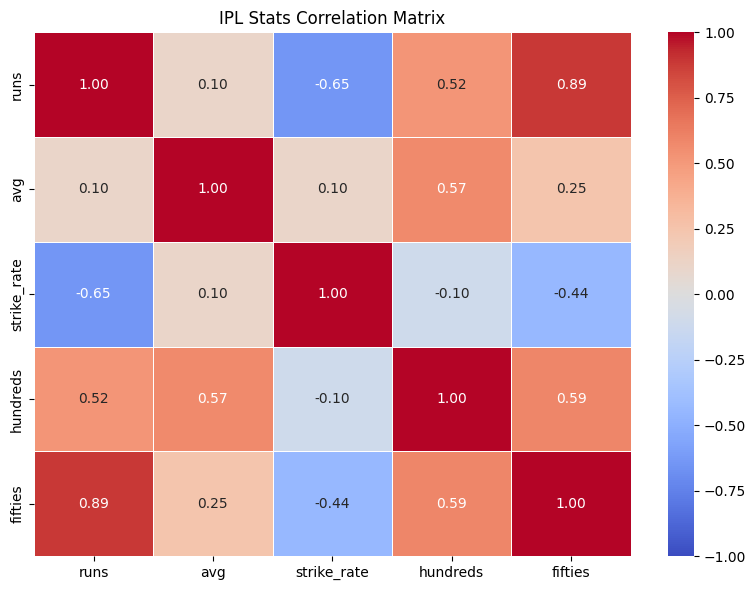

In [10]:
#Correlation Analysis

# Does higher average = higher strike rate?
corr = df[['runs', 'avg', 'strike_rate','hundreds', 'fifties']].corr()

print("Correlation Matrix:")
print(corr.round(3)) # round(3) means rounds all values to 3 decimal places

avg_sr_corr = df['avg'].corr(df['strike_rate'])
print(f"\n Average vs Strike Rate Correlation: {avg_sr_corr:.3f}")

if avg_sr_corr > 0.5:
    print("Strong Positive - Better Averge == Better Strike Rate")
elif avg_sr_corr > 0:
    print("Weak Positive - Slight Relationship")
else:
    print('Negative - Higher Avergae Doesn\'t mean higher strike rate')

#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt = '.2f', cmap = 'coolwarm',
           vmin = -1, vmax = 1, linewidths=0.5, linecolor='white')

plt.title('IPL Stats Correlation Matrix')
plt.tight_layout()
plt.show()

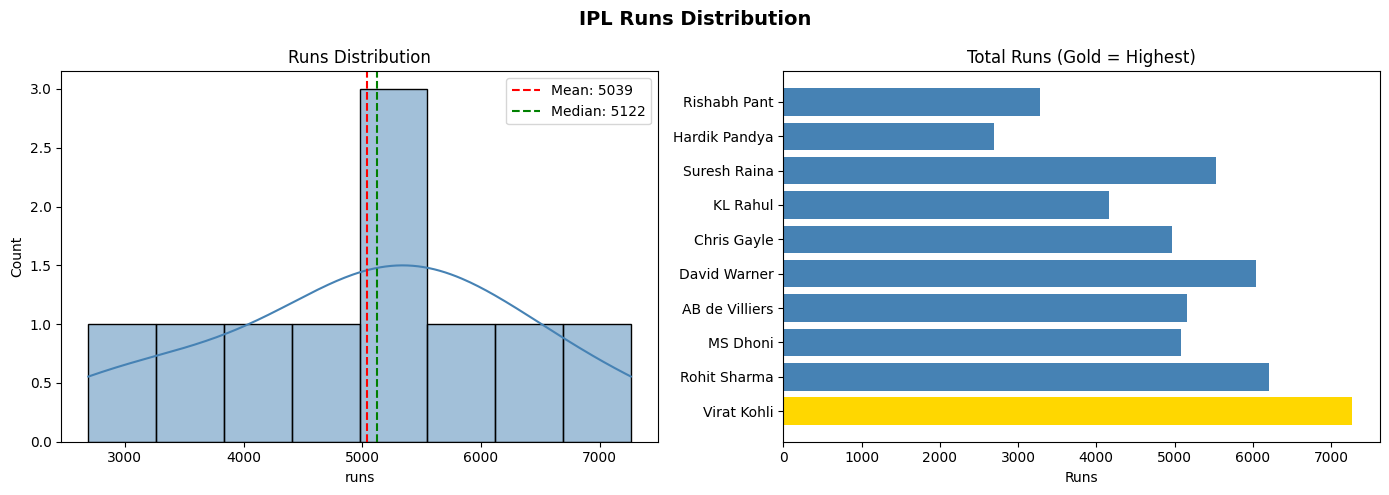

In [11]:
# Distribution of Runs

fig, axes = plt.subplots(1, 2, figsize = (14,5))
fig.suptitle('IPL Runs Distribution', fontsize = 14, fontweight = 'bold')

#Histogram
sns.histplot(df['runs'], bins = 8, kde = True, ax = axes[0], 
            color = 'steelblue')

axes[0].axvline(df['runs'].mean(), color = 'red', linestyle='--', 
               label = f'Mean: {df['runs'].mean():.0f}')
axes[0].axvline(df['runs'].median(), color = 'green', linestyle='--', 
               label = f'Median: {df['runs'].median():.0f}')

axes[0].set_title('Runs Distribution')
axes[0].legend()

# Bar Chart - Runs Per Player
colors = ['gold' if r == df['runs'].max() else 'steelblue'
          for r in df['runs']]
axes[1].barh(df['player'], df['runs'], color=colors)
axes[1].set_title('Total Runs (Gold = Highest)')
axes[1].set_xlabel('Runs')

plt.tight_layout()
plt.savefig('cricket_runs.png', dpi=150, bbox_inches='tight')
plt.show()


Overall Player Ranking (Z-Score Method)
  1. Chris Gayle: 0.832
  2. David Warner: 0.555
  3. AB de Villiers: 0.527
  4. Virat Kohli: 0.513
  5. KL Rahul: 0.202
  6. MS Dhoni: -0.325
  7. Rishabh Pant: -0.366
  8. Suresh Raina: -0.400
  9. Rohit Sharma: -0.682
  10. Hardik Pandya: -0.856


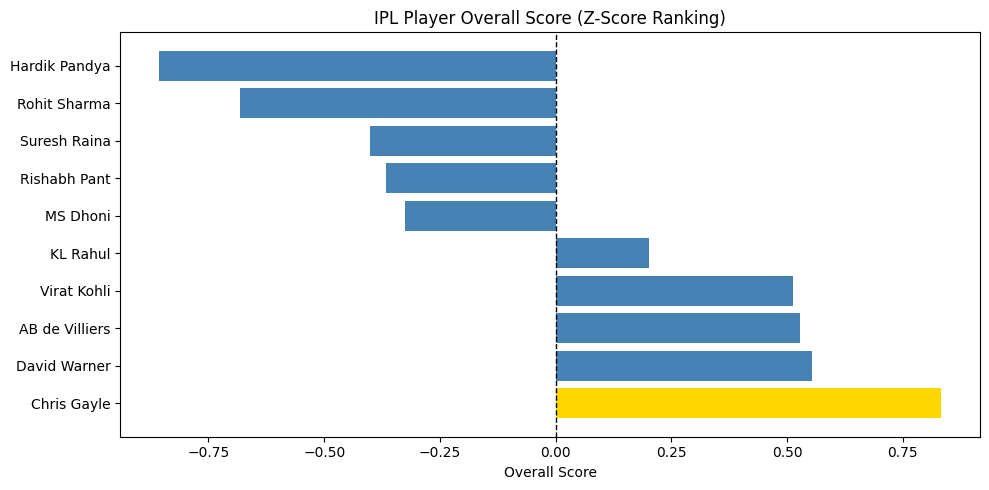

In [14]:
# Who is statistically best overall?
# Normalize all stats to same scale using z-scores

df['runs_z'] = stats.zscore(df['runs'])
df['avg_z'] = stats.zscore(df['avg'])
df['sr_z'] = stats.zscore(df['strike_rate'])
df['hundreds_z'] = stats.zscore(df['hundreds'])

# Overall score = average of all z-scores
df['overall_score'] = df[['runs_z', 'avg_z', 'sr_z', 'hundreds_z']].mean(axis=1)
df_ranked = df[['player', 'overall_score']].sort_values(
    'overall_score', ascending=False
)

print("Overall Player Ranking (Z-Score Method)")
for i, (_, row) in enumerate(df_ranked.iterrows(), 1):
    print(f"  {i}. {row['player']}: {row['overall_score']:.3f}")

# Bar chart
plt.figure(figsize=(10, 5))

colors = ['gold' if s == df_ranked['overall_score'].max()
          else 'steelblue' for s in df_ranked['overall_score']]

plt.barh(df_ranked['player'], df_ranked['overall_score'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title('IPL Player Overall Score (Z-Score Ranking)')
plt.xlabel('Overall Score')
plt.tight_layout()
plt.savefig('player_ranking.png', dpi=150, bbox_inches='tight')
plt.show()